In [1]:
# Load the "autoreload" extension so that code can change
%load_ext autoreload

# Reload modules so that as you change code in src, it gets loaded
%autoreload 2

In [2]:
import stackprinter

In [3]:
stackprinter.set_excepthook(style='darkbg2')

In [4]:
from pathlib import Path
import numpy as np
# import dask.array as da
# import xarray as xr

In [5]:
import muon as mu

In [6]:
mdata = mu.read(Path().home().joinpath("workspace", "scorphan", "tests", "5k_pbmc.h5mu"))

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [8]:
import numbers
import warnings
from typing import Final, Literal

import numpy as np
import numpy.typing as npt
from loguru import logger
from mudata import MuData
from muon._core.preproc import (
    _jaccard_euclidean_metric,
    _jaccard_sparse_euclidean_metric,
    _make_slice_intervals,
    _sparse_csr_fast_knn,
    _sparse_csr_ptp,
)
from scanpy.tools._utils import _choose_representation
from scipy.sparse import (
    SparseEfficiencyWarning,
    coo_array,
    csr_array,
    issparse,
)
from scipy.spatial.distance import cdist
from scipy.special import softmax

from scorphan.logging import init_logger

In [9]:
import scorphan as so

In [23]:
mdata.uns['wnn']['params']['use_rep']

{'rna': -1, 'prot': -1}

In [24]:
mdata_reweighted.uns['wnn']['params']

{'n_neighbors': 15,
 'n_multineighbors': 200,
 'metric': 'euclidean',
 'eps': 0.0001,
 'random_state': 42,
 'use_rep': {'rna': -1, 'prot': -1},
 'n_pcs': {'rna': -1, 'prot': -1},
 'method': 'umap'}

In [25]:
mdata_reweighted["rna"].uns["neighbors"]

{'connectivities_key': 'connectivities',
 'distances_key': 'distances',
 'params': {'method': 'umap',
  'metric': 'euclidean',
  'n_neighbors': np.int64(15),
  'random_state': np.int64(0)}}

In [10]:
so.pp.neighbors(mdata, modality_weights={"rna":0.4, "prot":0.6}, key_added="wnn", method="umap", verbose=True)

scorphan._preprocessing:neighbors:242 - Calculating kernel bandwidth for 'rna' modality...
scorphan._preprocessing:neighbors:267 - Using umap nearest_neighbors on 'rna' modality...
scorphan._preprocessing:neighbors:294 - Calculating cell affinities for 'rna modality...
scorphan._preprocessing:neighbors:242 - Calculating kernel bandwidth for 'prot' modality...
scorphan._preprocessing:neighbors:267 - Using umap nearest_neighbors on 'prot' modality...
scorphan._preprocessing:neighbors:294 - Calculating cell affinities for 'prot modality...
scorphan._preprocessing:neighbors:347 - Calculating nearest neighbor candidates for 'rna' modality...
scorphan._preprocessing:neighbors:348 - Using low_memory=False for 'rna' modality
scorphan._preprocessing:neighbors:376 - Using umap nearest_neighbors on 'rna' modality...
scorphan._preprocessing:neighbors:392 - Creating a sparse matrix from the neighbors calculations
scorphan._preprocessing:neighbors:347 - Calculating nearest neighbor candidates for 'p

In [11]:
mdata_reweighted = mdata.copy()

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [27]:
mdata_reweighted.uns

{'wnn': {'connectivities_key': 'wnn_connectivities',
  'distances_key': 'wnn_distances',
  'params': {'n_neighbors': 15,
   'n_multineighbors': 200,
   'metric': 'euclidean',
   'eps': 0.0001,
   'random_state': 42,
   'use_rep': {'rna': -1, 'prot': -1},
   'n_pcs': {'rna': -1, 'prot': -1},
   'method': 'umap'}},
 'leiden': {'params': {'resolution': None,
   'random_state': 0,
   'partition_improvement': 130751.53420093974}}}

#### mdata_reweighted.uns["wnn"] = mdata_reweighted.uns["wnn"].copy()

In [31]:
import scanpy as sc

In [32]:
sc.pp.neighbors(mdata['rna'])
sc.pp.neighbors(mdata['prot'])

In [34]:
so.pp.neighbors(mdata, modality_weights={"rna":0.4, "prot":0.6}, key_added="wnn", method="umap", verbose=True)

scorphan._preprocessing:neighbors:114 - Calculating kernel bandwidth for 'rna' modality...
scorphan._preprocessing:neighbors:129 - Using umap nearest_neighbors on 'rna' modality...
scorphan._preprocessing:neighbors:143 - Calculating cell affinities for 'rna modality...
scorphan._preprocessing:neighbors:114 - Calculating kernel bandwidth for 'prot' modality...
scorphan._preprocessing:neighbors:129 - Using umap nearest_neighbors on 'prot' modality...
scorphan._preprocessing:neighbors:143 - Calculating cell affinities for 'prot modality...
scorphan._preprocessing:neighbors:185 - Calculating nearest neighbor candidates for 'rna' modality...
scorphan._preprocessing:neighbors:186 - Using low_memory=False for 'rna' modality
scorphan._preprocessing:neighbors:199 - Using umap nearest_neighbors on 'rna' modality...
scorphan._preprocessing:neighbors:201 - Creating a sparse matrix from the neighbors calculations
scorphan._preprocessing:neighbors:185 - Calculating nearest neighbor candidates for 'p

In [41]:
mdata.uns["wnn"]['connectivities_key']

'wnn_connectivities'

In [40]:
mu.tl.leiden(mdata, key_added="leiden_reweighted", neighbors_key=list(mdata.uns.keys())[0])

KeyError: "No 'wnn' in .uns"

In [45]:
mu.tl.umap(mdata, neighbors_key='wnn', random_state=10)

In [46]:
sc.tl.leiden(mdata, resolution=1.0, neighbors_key='wnn', key_added='leiden_wnn')

/tmp/ipykernel_1953506/1375977937.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mdata, resolution=1.0, neighbors_key='wnn', key_added='leiden_wnn')


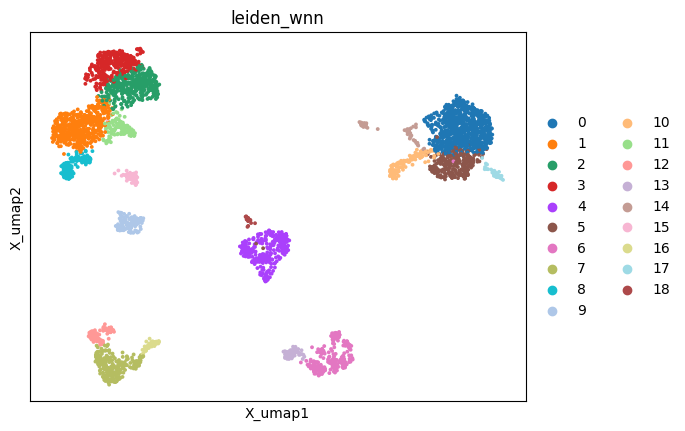

In [47]:
mu.pl.embedding(mdata, basis="X_umap", color="leiden_wnn")

In [48]:
original_mdata = mu.read(Path().home().joinpath("workspace", "scorphan", "tests", "5k_pbmc.h5mu"))

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [51]:
mu.pp.neighbors(original_mdata, key_added="wnn")
sc.tl.leiden(original_mdata, key_added="leiden_wnn", neighbors_key="wnn")
mu.tl.umap(original_mdata, neighbors_key="wnn", random_state=10)

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [54]:
mdata.uns

{'wnn': {'connectivities_key': 'wnn_connectivities',
  'distances_key': 'wnn_distances',
  'params': {'n_neighbors': 15,
   'n_multineighbors': 200,
   'metric': 'euclidean',
   'eps': 0.0001,
   'random_state': 42,
   'use_rep': {'rna': -1, 'prot': -1},
   'n_pcs': {'rna': -1, 'prot': -1},
   'method': 'umap'}},
 'umap': {'params': {'a': np.float64(0.5830300203968329),
   'b': np.float64(1.3341669926352966),
   'random_state': 10}},
 'leiden_wnn': {'params': {'resolution': 1.0,
   'random_state': 0,
   'n_iterations': -1}},
 'leiden_wnn_colors': ['#1f77b4',
  '#ff7f0e',
  '#279e68',
  '#d62728',
  '#aa40fc',
  '#8c564b',
  '#e377c2',
  '#b5bd61',
  '#17becf',
  '#aec7e8',
  '#ffbb78',
  '#98df8a',
  '#ff9896',
  '#c5b0d5',
  '#c49c94',
  '#f7b6d2',
  '#dbdb8d',
  '#9edae5',
  '#ad494a']}

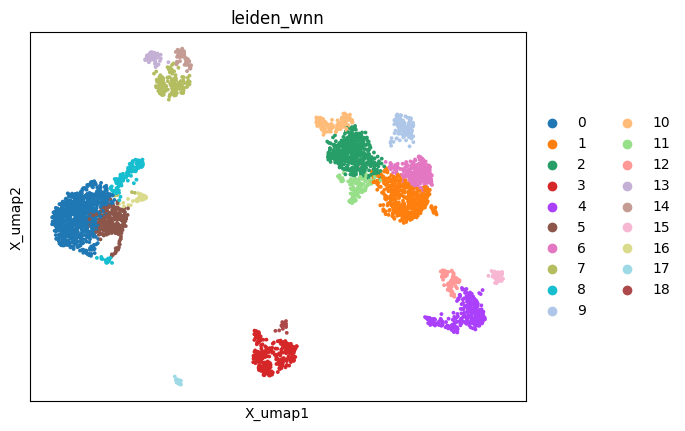

In [52]:
mu.pl.embedding(original_mdata, basis="X_umap", color="leiden_wnn")

In [42]:
from scanpy.tools._utils import _choose_graph

In [43]:
neighbors_key = "wnn"

In [44]:
adjacency = _choose_graph(mdata.mod["rna"], None, neighbors_key)

KeyError: "No 'wnn' in .uns"

In [ ]:
for mod in mdata.mod

In [ ]:
LARGE_NUMBER_OF_OBSERVATIONS: Final[int] = 50000
LOW_MEMORY_SPARSE_SPLITS: Final[int] = 10000
LARGE_MEMORY_SPARSE_SPLITS: Final[int] = 30000

In [9]:
def neighdist(rep, cell, nz, metric):
    if issparse(rep):
        return -cdist(rep[cell, :].toarray(), rep[nz, :].toarray(), metric=metric)
    else:
        return -cdist(rep[np.newaxis, cell, :], rep[nz, :], metric=metric)

In [10]:
modality_weights: dict[str, float] | None = None
manual_weights: dict[str, npt.ArrayLike] | None = None
n_neighbors: int | None = None
n_bandwidth_neighbors: int = 20
n_multineighbors: int = 200
neighbor_keys: dict[str, str | None] | None = None
metric: Literal[
    "euclidean",
    "braycurtis",
    "canberra",
    "chebyshev",
    "cityblock",
    "correlation",
    "cosine",
    "dice",
    "hamming",
    "jaccard",
    "jensenshannon",
    "kulsinski",
    "mahalanobis",
    "matching",
    "minkowski",
    "rogerstanimoto",
    "russellrao",
    "seuclidean",
    "sokalmichener",
    "sokalsneath",
    "sqeuclidean",
    "wminkowski",
    "yule",
] = "euclidean"
low_memory: bool | None = None
key_added: str | None = None
weight_key: str = "mod_weight"
add_weights_to_modalities: bool = False
eps: float = 1e-4
method: Literal["umap", "rapids"] = "umap"
copy: bool = False
random_state: int | np.random.RandomState | None = 42
verbose: bool = False

In [11]:
if method == "rapids":
    msg = "Sorry, GPU support is still a work in progress."
    raise NotImplementedError(msg)

In [12]:
if verbose:
    init_logger(verbose=3)
else:
    init_logger(verbose=2)

In [13]:
randomstate = np.random.RandomState(random_state)

In [14]:
mdata = mdata.copy() if copy else mdata
if neighbor_keys is None:
    modalities = mdata.mod.keys()
    neighbor_keys = {}
else:
    modalities = neighbor_keys.keys()

In [15]:
neighbors_params = {}
reps = {}
observations = mdata.obs.index

In [16]:
if low_memory or (low_memory is None and observations.size > LARGE_NUMBER_OF_OBSERVATIONS):
    sparse_matrix_assign_splits = LOW_MEMORY_SPARSE_SPLITS
else:
    sparse_matrix_assign_splits = LARGE_MEMORY_SPARSE_SPLITS

In [17]:
mod_neighbors = np.empty((len(modalities),), dtype=np.uint16)
mod_reps = {}
mod_n_pcs = {}

In [18]:
for i, mod in enumerate(modalities):
    nkey = neighbor_keys.get(mod, "neighbors")
    try:
        nparams = mdata.mod[mod].uns[nkey]
    except KeyError as err:
        msg = f'Did not find .uns["{nkey}"] for modality "{mod}". Run `sc.pp.neighbors` on all modalities first.'
        raise ValueError(msg) from err

    use_rep = nparams["params"].get("use_rep", None)
    n_pcs = nparams["params"].get("n_pcs", None)
    mod_neighbors[i] = nparams["params"].get("n_neighbors", 0)

    neighbors_params[mod] = nparams
    reps[mod] = _choose_representation(adata=mdata.mod[mod], use_rep=use_rep, n_pcs=n_pcs)
    mod_reps[mod] = use_rep if use_rep is not None else -1  # otherwise this is not saved to h5mu
    mod_n_pcs[mod] = n_pcs if n_pcs is not None else -1

In [19]:
if n_neighbors is None:
    mod_neighbors = mod_neighbors[mod_neighbors > 0]
    n_neighbors = int(round(np.mean(mod_neighbors), 0))

In [20]:
ratios = np.full((len(observations), len(modalities)), -np.inf, dtype=np.float64)
sigmas = {}

In [21]:
for i1, mod1 in enumerate(modalities):
    observations1 = observations.intersection(mdata.mod[mod1].obs.index)
    ratioidx = np.where(observations.isin(observations1))[0]
    nparams1 = neighbors_params[mod1]
    X = reps[mod1]  # noqa: N806
    neighbordistances = mdata.mod[mod1].obsp[nparams1["distances_key"]]
    nndistances = np.empty((neighbordistances.shape[0],), neighbordistances.dtype)
    # neighborsdistances is a sparse matrix, we can either convert to dense, or loop
    for i in range(neighbordistances.shape[0]):
        nndist = neighbordistances[i, :].data
        if nndist.size == 0:
            msg = (
                f"Cell {i} in modality {mod1} does not have any neighbors. "
                "This could be due to subsetting after nearest neighbors calculation. "
                "Make sure to subset before calculating nearest neighbors."
            )
            raise ValueError(msg)
        nndistances[i] = nndist.min()

    # We want to get the k-nn with the largest Jaccard distance, but break ties using
    # Euclidean distance. Largest Jaccard distance corresponds to lowest Jaccard index,
    # i.e. 1 - Jaccard distance. The naive version would be to compute pairwise Jaccard and
    # Euclidean distances for all points, but this is low and needs lots of memory. We
    # want to use an efficient k-nn algorithm, however no package that I know of supports
    # tie-breaking k-nn, so we use a custom distance. Jaccard index is always between 0 and 1
    # and has discrete increments of at least 1/N, where N is the number of data points.
    # If we scale the Jaccard indices by N, the minimum Jaccard index will be 1. If we scale
    # all Euclidean distances to be less than one, we can define a combined distance as the
    # sum of the scaled Jaccard index and one minus the Euclidean distances. This is not a
    # proper metric, but UMAP's nearest neighbor search uses NN-descent, which works with
    # arbitrary similarity measures.
    # The scaling factor for the Euclidean distance is given by the length of the diagonal
    # of the bounding box of the data. This can be computed in linear time by just taking
    # the minimal and maximal coordinates of each dimension.
    num_obs = X.shape[0]
    bbox_norm = np.linalg.norm(_sparse_csr_ptp(X) if issparse(X) else np.ptp(X, axis=0), ord=2)
    lmemory = low_memory if low_memory is not None else num_obs > LARGE_NUMBER_OF_OBSERVATIONS
    if issparse(X):
        X = X.tocsr()  # noqa: N806
        cmetric = _jaccard_sparse_euclidean_metric
        metric_kwds = {
            "X_indices": X.indices,
            "X_indptr": X.indptr,
            "X_data": X.data,
            "neighbors_indices": neighbordistances.indices,
            "neighbors_indptr": neighbordistances.indptr,
            "neighbors_data": neighbordistances.data,
            "N": num_obs,
            "bbox_norm": bbox_norm,
        }
    else:
        cmetric = _jaccard_euclidean_metric
        metric_kwds = {
            "X": X,
            "neighbors_indices": neighbordistances.indices,
            "neighbors_indptr": neighbordistances.indptr,
            "neighbors_data": neighbordistances.data,
            "N": num_obs,
            "bbox_norm": bbox_norm,
        }

    logger.info(f"Calculating kernel bandwidth for '{mod1}' modality...")
    if method == "rapids":
        logger.info(f"Using rapids nearest_neighbors on '{mod1}' modality...")
        try:
            from cuml.internals.device_support import GPU_ENABLED # I don't know why, but this often fails when cuml tries to do it
        except ImportError as exc:
            msg = "Please manually run `from cuml.internals.device_support import GPU_ENABLED`. Sometimes, it just fails."
            raise ImportError(msg) from exc
        from cuml.neighbors import NearestNeighbors

        x = np.arange(num_obs)[:, np.newaxis]
        nn = NearestNeighbors(
            n_neighbors=n_bandwidth_neighbors,
            algorithm="brute",
            metric=metric,
            output_type="cupy",
            metric_params=metric_kwds,
        )
        nn.fit(x)
        _, nn_indices = nn.kneighbors(
            X=x,
            n_neighbors=n_bandwidth_neighbors,
        )
        nn_indices = nn_indices.get()
    elif method == "umap":
        logger.debug(f"Using umap nearest_neighbors on '{mod1}' modality...")
        from umap.umap_ import nearest_neighbors

        nn_indices, _, _ = nearest_neighbors(
            X=np.arange(num_obs)[:, np.newaxis],
            n_neighbors=n_bandwidth_neighbors,
            metric=cmetric,
            metric_kwds=metric_kwds,
            random_state=randomstate,
            angular=False,
            low_memory=lmemory,
        )

    csigmas = np.empty((num_obs,), dtype=neighbordistances.dtype)
    if issparse(X):
        for i, neighbors in enumerate(nn_indices):
            csigmas[i] = cdist(X[i : (i + 1), :].toarray(), X[neighbors, :].toarray(), metric="euclidean").mean()
    else:
        for i, neighbors in enumerate(nn_indices):
            csigmas[i] = cdist(X[i : (i + 1), :], X[neighbors, :], metric="euclidean").mean()

    if not manual_weights:
        currtheta = None
        thetas = np.full((len(observations1), len(modalities) - 1), -np.inf, dtype=neighbordistances.dtype)

        lasti = 0

        logger.info(f"Calculating cell affinities for '{mod1} modality...")
        for i2, mod2 in enumerate(modalities):
            nparams2 = neighbors_params[mod2]
            neighbordistances = mdata.mod[mod2].obsp[nparams2["distances_key"]]
            observations2 = observations1.intersection(mdata.mod[mod2].obs.index)
            Xidx = np.where(observations1.isin(observations2))[0]  # noqa: N806
            r = np.empty(shape=(len(observations2), X.shape[1]), dtype=neighbordistances.dtype)
            # alternative to the loop would be broadcasting, but this requires converting the sparse
            # connectivity matrix to a dense ndarray and producing a temporary 3d array of size
            # n_cells x n_cells x n_genes => requires a lot of memory
            for i, cell in enumerate(Xidx):
                r[i, :] = np.asarray(np.mean(X[neighbordistances[cell, :].nonzero()[1], :], axis=0)).squeeze()

            theta = np.exp(
                -np.maximum(np.linalg.norm(X[Xidx, :] - r, ord=2, axis=-1) - nndistances[Xidx], 0)
                / (csigmas[Xidx] - nndistances[Xidx])
            )
            if i1 == i2:
                currtheta = theta
            else:
                thetas[:, lasti] = theta
                lasti += 1
        ratios[ratioidx, i1] = currtheta / (np.max(thetas, axis=1) + eps)
    sigmas[mod1] = csigmas

In [22]:
if manual_weights:
    for mod in modalities:
        if mod not in manual_weights:
            msg = f"A weight was not suppied for the {mod} modality"
            raise ValueError(msg)
    weights = np.empty((len(mdata.obs), len(modalities)))
    for i, mod in enumerate(manual_weights):
        if isinstance(manual_weights[mod], numbers.Number):
            manual_weights[mod] = np.broadcast_to(manual_weights[mod], len(mdata[mod].obs))
        if len(manual_weights[mod]) != len(mdata[mod].obs):
            msg = f"The length of the weight array for {mod} does not match the number of cells. Either suppy a single value or one for each cell"
            raise ValueError(msg)
        weights[:, i] = manual_weights[mod]
else:
    weights = softmax(ratios, axis=1)

In [23]:
neighbordistances = csr_array((mdata.n_obs, mdata.n_obs), dtype=np.float64)

In [24]:
# neighbordistances = np.empty((mdata.n_obs, mdata.n_obs), dtype=np.int64)
largeidx = mdata.n_obs**2 > np.iinfo(np.int32).max

In [25]:
if largeidx:  # work around scipy bug https://github.com/scipy/scipy/issues/13155
    neighbordistances.indptr = neighbordistances.indptr.astype(np.int64)
    neighbordistances.indices = neighbordistances.indices.astype(np.int64)

In [26]:
for _, m in enumerate(modalities):
    cmetric = neighbors_params[m].get("metric", "euclidean")
    observations1 = observations.intersection(mdata.mod[m].obs.index)

    rep = reps[m]
    lmemory = low_memory if low_memory is not None else rep.shape[0] > LARGE_NUMBER_OF_OBSERVATIONS
    logger.info(f"Calculating nearest neighbor candidates for '{m}' modality...")
    logger.debug(f"Using low_memory={lmemory} for '{m}' modality")

    if method == "rapids":
        logger.debug(f"Using rapids nearest_neighbors on '{m}' modality...")
        nn = NearestNeighbors(
                n_neighbors=n_bandwidth_neighbors,
                algorithm="brute",
                metric=cmetric,
                output_type="cupy",
                metric_params=metric_kwds,
            )
        logger.debug(f"Fitting nearest_neighbors...")
        nn.fit(rep)
        logger.debug(f"Calculating distances, nn_indices...")
        distances, nn_indices = nn.kneighbors(
            X=rep,
            n_neighbors=n_bandwidth_neighbors,
        )
        logger.debug(f"Getting indices...")
        nn_indices = nn_indices.get()
        logger.debug(f"Getting distances...")
        distances = distances.get()
        # return {
        #     "distances": distances,
        #     "nn_indices": nn_indices,
        #     "n_multineighbors": n_multineighbors,
        # }
    elif method == "umap":
        logger.debug(f"Using umap nearest_neighbors on '{m}' modality...")
        nn_indices, distances, _ = nearest_neighbors(
            rep,
            n_neighbors=n_multineighbors + 1,
            metric=cmetric,
            metric_kwds={},
            random_state=randomstate,
            angular=False,
            low_memory=lmemory,
        )
        # return {
        #     "distances": distances,
        #     "nn_indices": nn_indices,
        #     "n_multineighbors": n_multineighbors,
        # }

    logger.debug("Creating a sparse matrix from the neighbors calculations")
    graph = csr_array(
        (
            distances[:, 1:].reshape(-1),
            nn_indices[:, 1:].reshape(-1),
            np.concatenate((nn_indices[:, 0] * n_multineighbors, (nn_indices[:, 1:].size,))),
        ),
        shape=(rep.shape[0], rep.shape[0]),
    )
    with warnings.catch_warnings():
        # CSR is faster here than LIL, no matter what SciPy says
        warnings.simplefilter("ignore", category=SparseEfficiencyWarning)
        if observations1.size == observations.size:
            if neighbordistances.size == 0:
                # logger.debug("Using neighborhood graph for neighbor distances")
                neighbordistances = graph
                # logger.debug(".")
            else:
                # logger.debug("Adding neighborhood graph to neighbor distances")
                # logger.debug(f"neighbordistances dims: {neighbordistances.shape}, type: {type(neighbordistances)}")
                # logger.debug(f"graph dims: {graph.shape}, type: {type(graph)}")
                # return neighbordistances, graph
                neighbordistances = csr_array(neighbordistances + graph)
                
        # the naive version of neighbordistances[idx[:, np.newaxis], idx[np.newaxis, :]] += graph
        else:
            # uses way too much memory
            if largeidx:
                graph.indptr = graph.indptr.astype(np.int64)
                graph.indices = graph.indices.astype(np.int64)
            fullstarts, fullstops = _make_slice_intervals(
                np.where(observations.isin(observations1))[0], sparse_matrix_assign_splits
            )
            modstarts, modstops = _make_slice_intervals(
                np.where(mdata.mod[m].obs.index.isin(observations1))[0],
                sparse_matrix_assign_splits,
            )
            for fullidxstart1, fullidxstop1, modidxstart1, modidxstop1 in zip(
                fullstarts, fullstops, modstarts, modstops, strict=False
            ):
                for fullidxstart2, fullidxstop2, modidxstart2, modidxstop2 in zip(
                    fullstarts, fullstops, modstarts, modstops, strict=False
                ):
                    neighbordistances[fullidxstart1:fullidxstop1, fullidxstart2:fullidxstop2] += graph[
                        modidxstart1:modidxstop1, modidxstart2:modidxstop2
                    ]

In [27]:
neighbordistances.data[:] = 0
logger.info("Calculating multimodal nearest neighbors...")
if modality_weights is None:
    modality_weights = {_: 1 for _ in modalities}
if len(modality_weights) != len(modalities):
    msg = "Number of weights in modality_weights does not match the actual number of modalities!"
    raise ValueError(msg)

In [54]:
modalities

dict_keys(['rna', 'prot'])

In [55]:
i = 0
m = "rna"

In [56]:
observations1 = observations.intersection(mdata.mod[m].obs.index)

In [35]:
fullidx = np.where(observations.isin(observations1))[0]

In [36]:
if weight_key:
    if add_weights_to_modalities:
        mdata.mod[m].obs[weight_key] = weights[fullidx, i] * modality_weights[m]
    else:
        # mod_weight -> mod:mod_weight
        mdata.obs[":".join([m, weight_key])] = weights[fullidx, i] * modality_weights[m]

In [37]:
rep = reps[m]

In [38]:
csigmas = sigmas[m]

In [40]:
neighbordistances

<Compressed Sparse Row sparse array of dtype 'float64'
	with 1323083 stored elements and shape (3965, 3965)>

In [ ]:
# neighbordistances.data = neighbordistances.astype(np.float64)

In [42]:
cell

0

In [43]:
row = slice(neighbordistances.indptr[cell], neighbordistances.indptr[cell + 1])

In [44]:
row

slice(np.int64(0), np.int64(348), None)

In [45]:
nz = neighbordistances.indices[row]

In [46]:
nz

array([1784, 3210, 3205, 2235, 3815, 3199, 2848, 3617,  130, 3286, 3558,
       1257, 3832, 2227,  567, 1740,   40, 2664, 2754, 2176, 3772,  742,
       1501, 1149,  406,  626, 1431, 1642, 2963, 3895, 3037, 2027, 3248,
        940, 1601, 3217, 2560, 1085, 2919,  592, 3062, 3396, 3884, 1708,
       1704, 3901, 3707,  150, 3085, 3516,  903, 2359,  383, 2778, 1739,
       1309, 1496, 3719, 2727, 1379, 3838, 3077, 1745, 2428, 2678, 1307,
       1059, 3020,  552, 1521, 2114, 2339, 3449, 3394, 2545, 3229, 3849,
       2197, 2296,  636, 3067, 3507, 1774,  676, 3482, 1842,  621,  112,
        448, 2828, 1386,  290, 1453, 1507,   25, 2258,  722, 3060, 3330,
       3296, 2447, 1627, 3446,  321, 2456, 2660,  300, 1820, 1104, 1329,
       2712, 3645, 1580, 3200, 1289, 2995, 3784, 1611, 1587,  503, 2819,
       2542, 3757,  985, 3154,  528, 2017, 2479, 1690, 3422, 1621, 2981,
       2797,  464, 3763, 3794,  967, 1413, 2710, 3350,   97, 2559, 3879,
       3109, 3161, 3263, 1128,  951, 1290, 2617,  4

In [48]:
neighbordistances.data[row].todense()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(348, 3965))

In [49]:
(
    np.exp(neighdist(rep, cell, nz, metric) / csigmas[cell]).squeeze()
    * weights[cell, i]
    * modality_weights[m]
)

array([0.12041663, 0.1252261 , 0.109741  , 0.06976025, 0.07613623,
       0.09954714, 0.11037534, 0.10725327, 0.11507553, 0.12427443,
       0.09237481, 0.10851523, 0.11370538, 0.10856562, 0.10747558,
       0.09553425, 0.11165225, 0.12061676, 0.11276111, 0.1149773 ,
       0.09629106, 0.12314343, 0.1113059 , 0.10953969, 0.12860793,
       0.11011453, 0.12167678, 0.10918352, 0.03973469, 0.12019219,
       0.10974774, 0.11277789, 0.10957174, 0.11555468, 0.11962274,
       0.12084017, 0.1162642 , 0.12796196, 0.1161725 , 0.12416259,
       0.11571981, 0.11615194, 0.12906264, 0.10848963, 0.11769653,
       0.11857524, 0.04883432, 0.11432955, 0.08310306, 0.12649668,
       0.12429274, 0.11770917, 0.12948028, 0.10452231, 0.09005147,
       0.09062772, 0.12412125, 0.12552089, 0.12660518, 0.09902386,
       0.12118307, 0.10740162, 0.11599233, 0.10892237, 0.08387507,
       0.12759165, 0.12050974, 0.10081027, 0.11062584, 0.09478074,
       0.09976981, 0.11957399, 0.0976279 , 0.08474224, 0.12160

In [41]:
for cell, _ in enumerate(fullidx):
    row = slice(neighbordistances.indptr[cell], neighbordistances.indptr[cell + 1])
    nz = neighbordistances.indices[row]
    neighbordistances.data[row] += (
        np.exp(neighdist(rep, cell, nz, metric) / csigmas[cell]).squeeze()
        * weights[cell, i]
        * modality_weights[m]
    )

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (348,)  and requested shape (348,3965)

In [28]:
for i, m in enumerate(modalities):
    observations1 = observations.intersection(mdata.mod[m].obs.index)
    fullidx = np.where(observations.isin(observations1))[0]

    if weight_key:
        if add_weights_to_modalities:
            mdata.mod[m].obs[weight_key] = weights[fullidx, i] * modality_weights[m]
        else:
            # mod_weight -> mod:mod_weight
            mdata.obs[":".join([m, weight_key])] = weights[fullidx, i] * modality_weights[m]

    rep = reps[m]
    csigmas = sigmas[m]
    # neighbordistances.data = neighbordistances.astype(np.float64)
    for cell, _ in enumerate(fullidx):
        row = slice(neighbordistances.indptr[cell], neighbordistances.indptr[cell + 1])
        nz = neighbordistances.indices[row]
        neighbordistances.data[row] += (
            np.exp(neighdist(rep, cell, nz, metric) / csigmas[cell]).squeeze()
            * weights[cell, i]
            * modality_weights[m]
        )

In [29]:
neighbordistances.data = np.sqrt(0.5 * (1 - neighbordistances.data))

In [30]:
neighbordistances = _sparse_csr_fast_knn(neighbordistances, n_neighbors + 1)

In [31]:
logger.info("Calculating connectivities...")

In [32]:
if method == "rapids":
    try:
        from cuml.manifold.simpl_set import fuzzy_simplicial_set
        logger.debug("Imported `fuzzy_simplicial_set` from `rapids`")
    except ImportError as err:
        msg = "cuml could not be imported - is it installed?"
        raise ImportError(msg) from err
elif method == "umap":
    from umap.umap_ import fuzzy_simplicial_set
    logger.debug("Imported `fuzzy_simplicial_set` from `umap`")

In [34]:
connectivities, _, _ = fuzzy_simplicial_set(
    X=coo_array((neighbordistances.shape[0], 1)),
    n_neighbors=n_neighbors + 1,
    random_state=None,
    metric="euclidean",
    knn_indices=neighbordistances.indices.reshape((neighbordistances.shape[0], n_neighbors + 1)),
    knn_dists=neighbordistances.data.reshape((neighbordistances.shape[0], n_neighbors + 1)),
    set_op_mix_ratio=1.0,
    local_connectivity=1.0,
)

In [35]:
if key_added is None:
    key_added = "neighbors"
    conns_key = "connectivities"
    dists_key = "distances"
else:
    conns_key = key_added + "_connectivities"
    dists_key = key_added + "_distances"

In [36]:
neighbors_dict = {"connectivities_key": conns_key, "distances_key": dists_key}
neighbors_dict["params"] = {
    "n_neighbors": n_neighbors,
    "n_multineighbors": n_multineighbors,
    "metric": metric,
    "eps": eps,
    "random_state": random_state,
    "use_rep": mod_reps,
    "n_pcs": mod_n_pcs,
    "method": method,
}
mdata.obsp[dists_key] = neighbordistances
mdata.obsp[conns_key] = connectivities
mdata.uns[key_added] = neighbors_dict

mdata.update_obs()

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [37]:
    return mdata if copy else None

SyntaxError: 'return' outside function (1593605087.py, line 1)